# PCA Analysis of Coefficient Fields

Determines how many dimensions are needed to capture the variance in each problem's coefficient field.
This informs the choice of `BETA_SIZE` for each encoder.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import h5py
from pathlib import Path
from sklearn.decomposition import PCA

FIGURE_DIR = Path('figures/pca_analysis')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

THRESHOLDS = [0.50, 0.90, 0.95, 0.99, 0.9999]
THRESHOLD_LABELS = ['50%', '90%', '95%', '99%', '99.99%']

## 1. Load Data

In [2]:
# Darcy Continuous: coeff (29,29,1000) → (1000, 841)
with h5py.File('../data/darcy_continuous/smh_train.mat', 'r') as f:
    coeff_dc = np.array(f['coeff']).T  # (1000, 29, 29)
    X_dc = np.array(f['X']).T         # (29, 29)
    Y_dc = np.array(f['Y']).T         # (29, 29)

A_dc = coeff_dc.reshape(coeff_dc.shape[0], -1)  # (1000, 841)
print(f'Darcy Continuous: {A_dc.shape}, range [{A_dc.min():.2f}, {A_dc.max():.2f}]')

# Darcy Piecewise: coe (10000, 29, 29) → (10000, 841)
with h5py.File('../data/darcy_piecewise/pwc_train_data10000.mat', 'r') as f:
    coe_dp = np.array(f['coe'])  # (10000, 29, 29) — no transpose needed
    X_dp = np.array(f['X'])      # (29, 29)
    Y_dp = np.array(f['Y'])      # (29, 29)

A_dp = coe_dp.reshape(coe_dp.shape[0], -1)  # (10000, 841)
print(f'Darcy Piecewise: {A_dp.shape}, range [{A_dp.min():.2f}, {A_dp.max():.2f}]')

# EIT: a_sol (32,32,20000) → (20000, 1024)
with h5py.File('../data/eit/train_withData_EIT.mat', 'r') as f:
    a_eit = np.array(f['a_sol']).T  # (20000, 32, 32)
    X_eit = np.array(f['X']).T      # (32, 32)
    Y_eit = np.array(f['Y']).T      # (32, 32)

A_eit = a_eit.reshape(a_eit.shape[0], -1)  # (20000, 1024)
print(f'EIT:             {A_eit.shape}, range [{A_eit.min():.2f}, {A_eit.max():.2f}]')

# Burgers: u0 initial conditions (128, 1000) → (1000, 128)
with h5py.File('../data/burgers/viscid_train.mat', 'r') as f:
    u0_burg = np.array(f['u0']).T      # (1000, 128)
    x_burg = np.array(f['x_mesh']).flatten()  # (128,)

A_burg = u0_burg  # (1000, 128) — each sample is a 1D initial condition
print(f'Burgers:         {A_burg.shape}, range [{A_burg.min():.2f}, {A_burg.max():.2f}]')

Darcy Continuous: (1000, 841), range [0.10, 4.10]
Darcy Piecewise: (10000, 841), range [5.00, 10.00]
EIT:             (20000, 1024), range [0.38, 7.43]
Burgers:         (1000, 128), range [-1.59, 1.59]


## 2. Fit PCA

In [3]:
datasets = [
    ('Darcy Continuous', A_dc, X_dc, Y_dc, (29, 29)),
    ('Darcy Piecewise',  A_dp, X_dp, Y_dp, (29, 29)),
    ('EIT',              A_eit, X_eit, Y_eit, (32, 32)),
]

pcas = {}
for name, A, *_ in datasets:
    pca = PCA()
    pca.fit(A)
    pcas[name] = pca
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    dims = {f'{int(t*100)}%' if t < 1 else '99.99%': int(np.searchsorted(cumvar, t) + 1)
            for t in THRESHOLDS}
    print(f'{name}: n_components={pca.n_components_}, dims={dims}')

# Burgers — 1D problem, fit separately
pca_burg = PCA()
pca_burg.fit(A_burg)
pcas['Burgers'] = pca_burg
cumvar_burg = np.cumsum(pca_burg.explained_variance_ratio_)
dims_burg = {f'{int(t*100)}%' if t < 1 else '99.99%': int(np.searchsorted(cumvar_burg, t) + 1)
             for t in THRESHOLDS}
print(f'Burgers: n_components={pca_burg.n_components_}, dims={dims_burg}')

Darcy Continuous: n_components=841, dims={'50%': 1, '90%': 3, '95%': 4, '99%': 6}
Darcy Piecewise: n_components=841, dims={'50%': 4, '90%': 109, '95%': 291, '99%': 839}
EIT: n_components=1024, dims={'50%': 1, '90%': 2, '95%': 3, '99%': 8}
Burgers: n_components=128, dims={'50%': 1, '90%': 3, '95%': 3, '99%': 19}


## 3. Summary Table

In [4]:
rows = []
for name, A, *_ in datasets:
    pca = pcas[name]
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    row = {'Dataset': name, 'N_samples': A.shape[0], 'D_features': A.shape[1]}
    for t, label in zip(THRESHOLDS, THRESHOLD_LABELS):
        row[label] = int(np.searchsorted(cumvar, t) + 1)
    rows.append(row)

# Add Burgers row
pca = pcas['Burgers']
cumvar = np.cumsum(pca.explained_variance_ratio_)
row = {'Dataset': 'Burgers', 'N_samples': A_burg.shape[0], 'D_features': A_burg.shape[1]}
for t, label in zip(THRESHOLDS, THRESHOLD_LABELS):
    row[label] = int(np.searchsorted(cumvar, t) + 1)
rows.append(row)

df = pd.DataFrame(rows).set_index('Dataset')
display(df)

,N_samples,D_features,50%,90%,95%,99%,99.99%
Dataset,,,,,,,
Darcy Continuous,1000,841,1,3,4,4,6
Darcy Piecewise,10000,841,4,109,291,658,839
EIT,20000,1024,1,2,3,5,8
Burgers,1000,128,1,3,3,6,19


## 4. Scree Plots

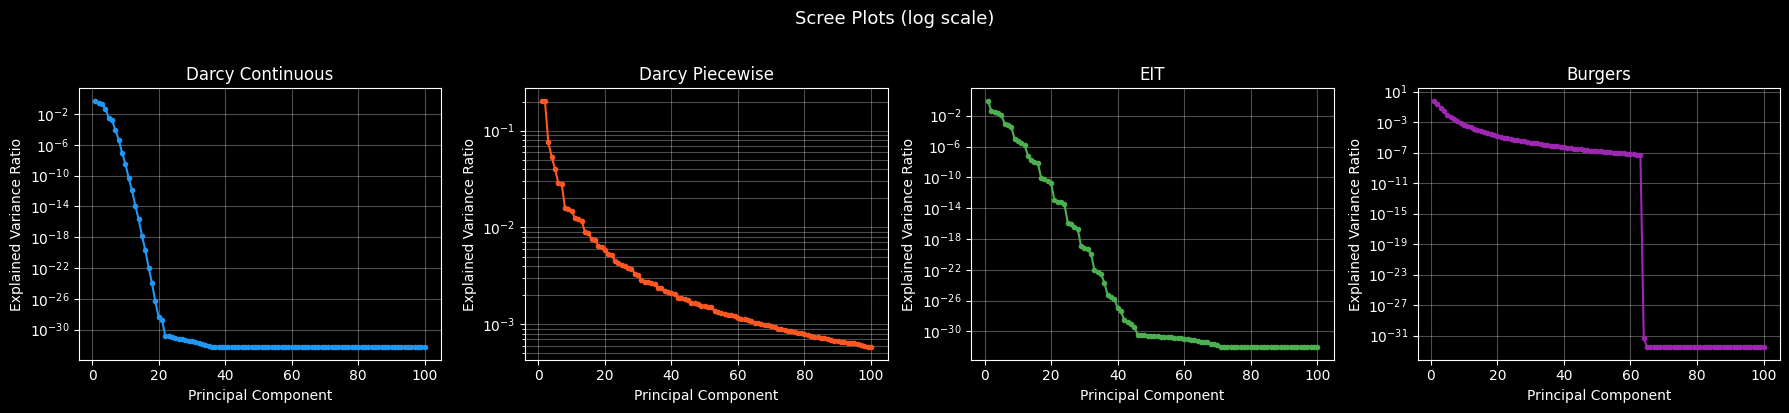

In [5]:
colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
all_datasets_for_plots = datasets + [('Burgers', A_burg, x_burg, None, (128,))]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, A, *_), color in zip(axes, all_datasets_for_plots, colors):
    pca = pcas[name]
    n_show = min(100, pca.n_components_)
    ax.semilogy(np.arange(1, n_show + 1), pca.explained_variance_ratio_[:n_show],
                'o-', color=color, ms=3, lw=1.5)
    ax.set_xlabel('Principal Component')
    ax.set_ylabel('Explained Variance Ratio')
    ax.set_title(name)
    ax.grid(True, which='both', alpha=0.3)

fig.suptitle('Scree Plots (log scale)', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'scree_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Cumulative Variance Explained

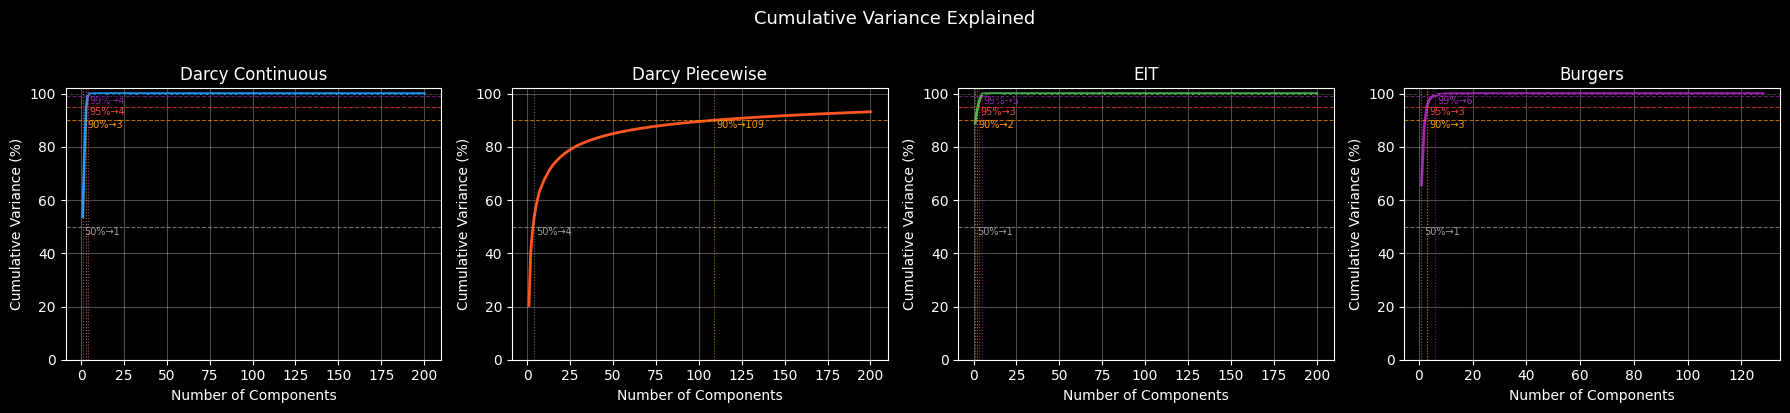

In [6]:
threshold_colors = ['#9E9E9E', '#FF9800', '#F44336', '#9C27B0', '#000000']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, A, *_), color in zip(axes, all_datasets_for_plots, colors):
    pca = pcas[name]
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    n_show = min(200, pca.n_components_)
    ax.plot(np.arange(1, n_show + 1), cumvar[:n_show] * 100,
            color=color, lw=2)

    # Threshold lines
    for t, label, tc in zip(THRESHOLDS, THRESHOLD_LABELS, threshold_colors):
        d = int(np.searchsorted(cumvar, t) + 1)
        if d <= n_show:
            ax.axhline(t * 100, ls='--', lw=0.8, color=tc, alpha=0.7)
            ax.axvline(d, ls=':', lw=0.8, color=tc, alpha=0.7)
            ax.annotate(f'{label}→{d}', xy=(d, t * 100),
                        xytext=(d + 1, t * 100 - 3), fontsize=7, color=tc)

    ax.set_xlabel('Number of Components')
    ax.set_ylabel('Cumulative Variance (%)')
    ax.set_title(name)
    ax.set_ylim(0, 102)
    ax.grid(True, alpha=0.3)

fig.suptitle('Cumulative Variance Explained', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'cumvar_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Top Principal Components (Spatial Modes)

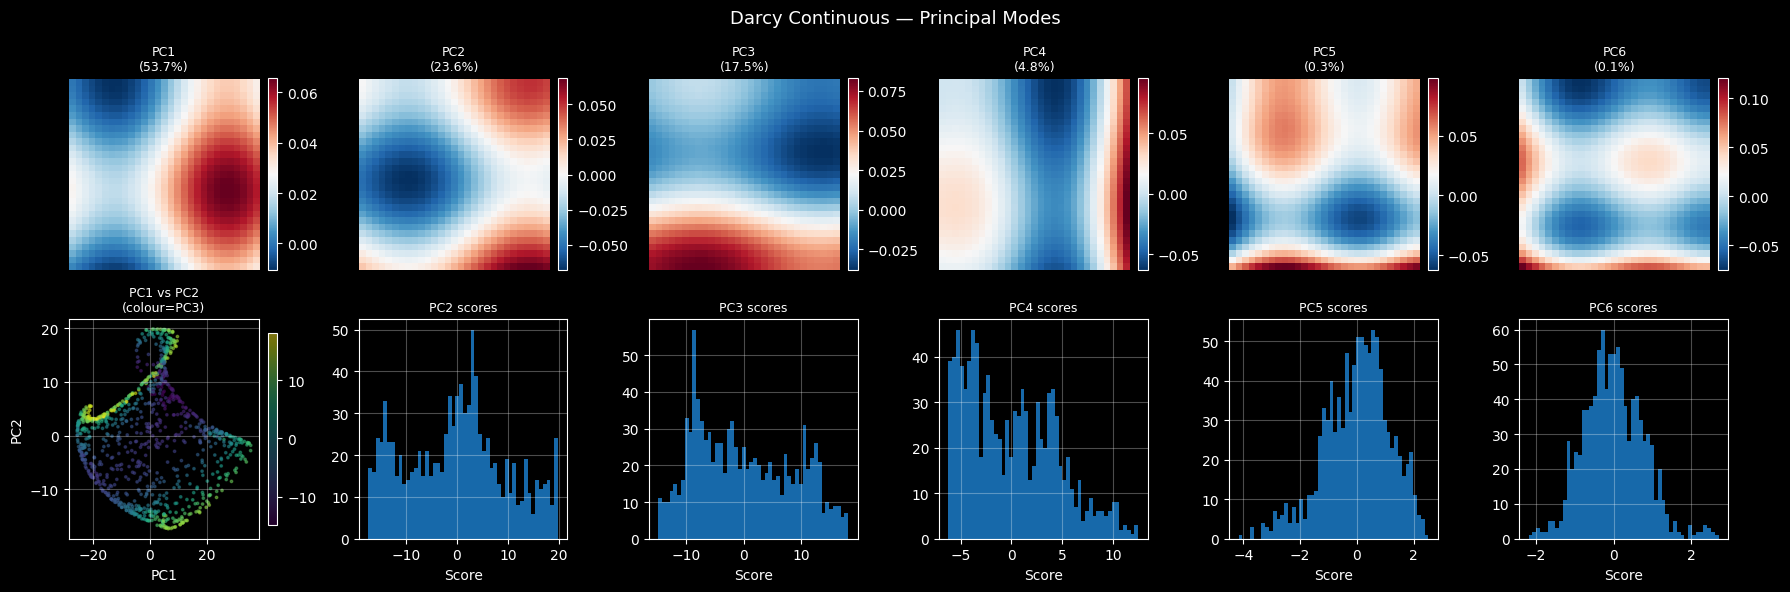

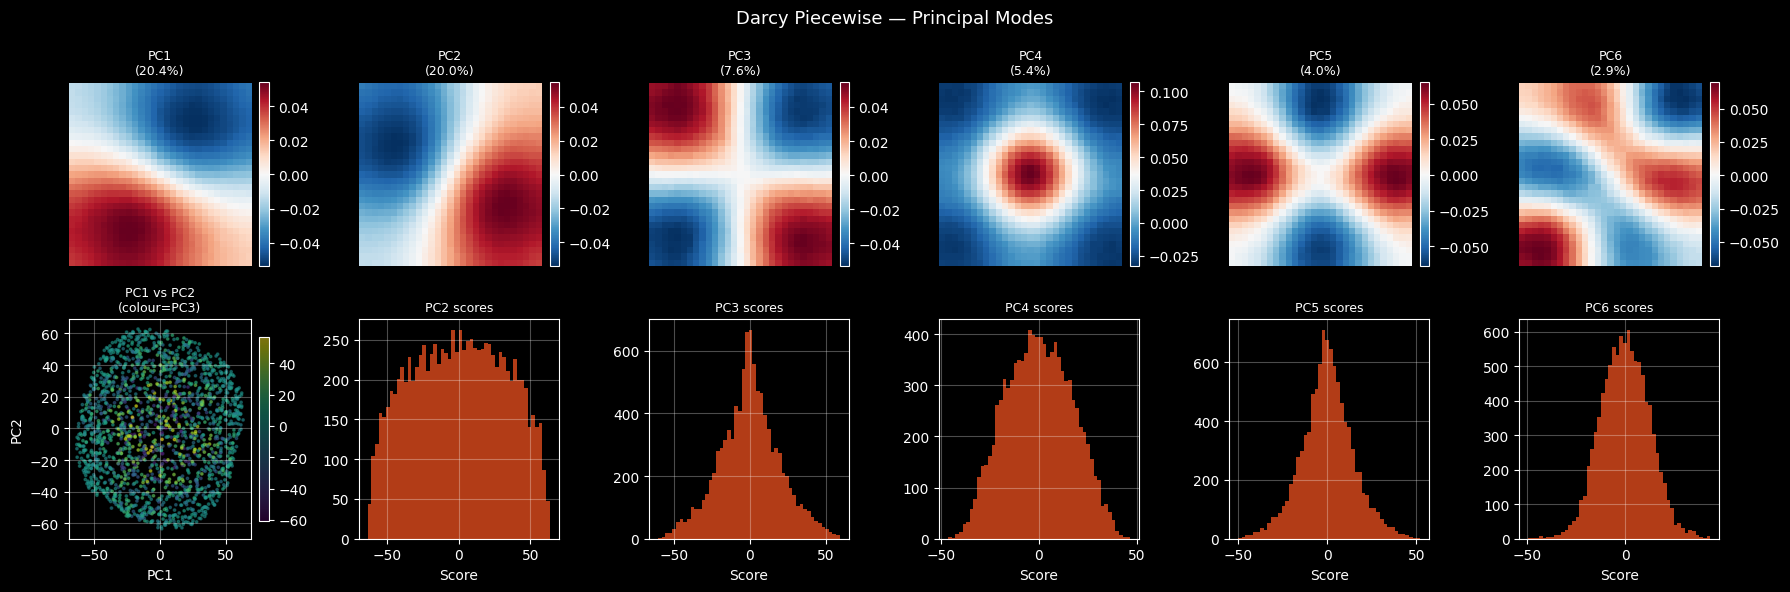

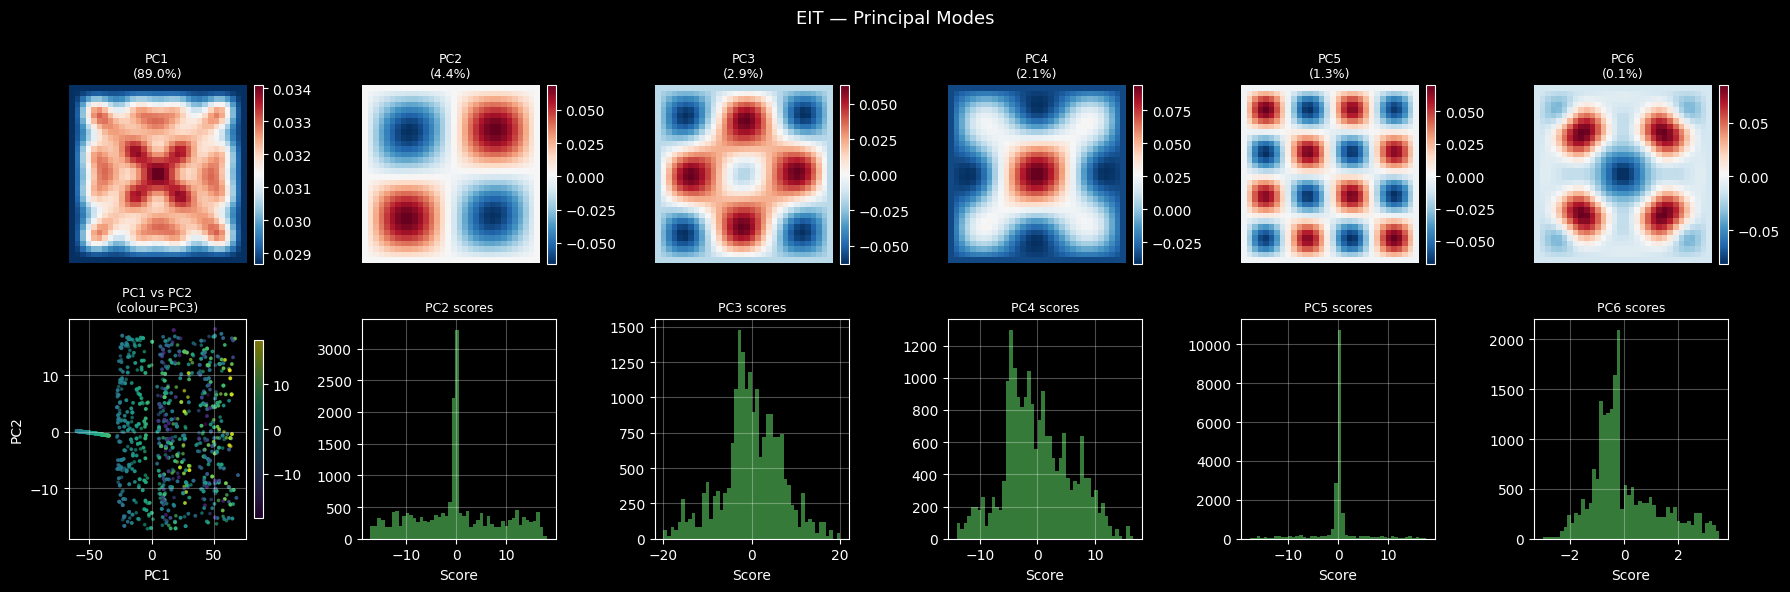

In [7]:
N_MODES = 6

for name, A, Xg, Yg, grid_shape in datasets:
    pca = pcas[name]
    H, W = grid_shape

    fig, axes = plt.subplots(2, N_MODES, figsize=(3 * N_MODES, 6))

    # Row 1: PC spatial modes
    for i in range(N_MODES):
        mode = pca.components_[i].reshape(H, W)
        im = axes[0, i].imshow(mode, cmap='RdBu_r', aspect='equal')
        var_pct = pca.explained_variance_ratio_[i] * 100
        axes[0, i].set_title(f'PC{i+1}\n({var_pct:.1f}%)', fontsize=9)
        axes[0, i].axis('off')
        fig.colorbar(im, ax=axes[0, i], fraction=0.046, pad=0.04)

    # Row 2: sample projections — project training data onto first 2 PCs
    Z = pca.transform(A)  # (N, n_components)
    # Scatter PC1 vs PC2, coloured by PC3 score
    n_plot = min(2000, A.shape[0])
    idx = np.random.choice(A.shape[0], n_plot, replace=False)
    sc = axes[1, 0].scatter(Z[idx, 0], Z[idx, 1], c=Z[idx, 2] if Z.shape[1] > 2 else 'steelblue',
                             s=3, alpha=0.5, cmap='viridis')
    axes[1, 0].set_xlabel('PC1')
    axes[1, 0].set_ylabel('PC2')
    axes[1, 0].set_title('PC1 vs PC2\n(colour=PC3)' if Z.shape[1] > 2 else 'PC1 vs PC2',
                          fontsize=9)
    axes[1, 0].grid(True, alpha=0.3)
    if Z.shape[1] > 2:
        fig.colorbar(sc, ax=axes[1, 0], fraction=0.046, pad=0.04)

    # PC score distributions for the first few dims
    for i in range(1, N_MODES):
        axes[1, i].hist(Z[:, i], bins=50, color=colors[datasets.index((name, A, Xg, Yg, grid_shape))],
                        alpha=0.7, edgecolor='none')
        axes[1, i].set_title(f'PC{i+1} scores', fontsize=9)
        axes[1, i].set_xlabel('Score')
        axes[1, i].grid(True, alpha=0.3)

    fig.suptitle(f'{name} — Principal Modes', fontsize=13)
    fig.tight_layout()
    fname = name.lower().replace(' ', '_')
    fig.savefig(FIGURE_DIR / f'modes_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print()

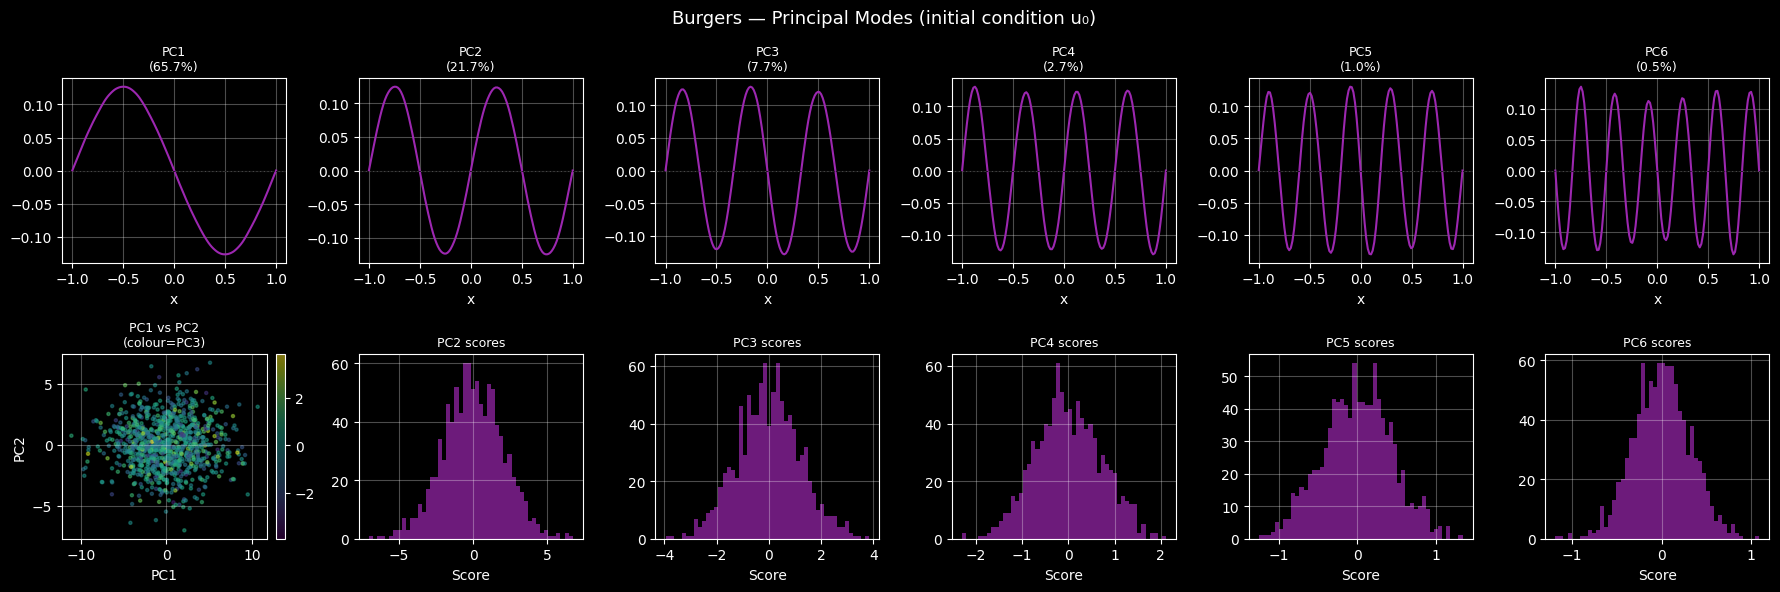

In [8]:
# Burgers spatial modes — 1D line plots (initial condition u0)
N_MODES = 6
color_burg = '#9C27B0'

fig, axes = plt.subplots(2, N_MODES, figsize=(3 * N_MODES, 6))

# Row 1: PC spatial modes as 1D line plots
for i in range(N_MODES):
    mode = pca_burg.components_[i]  # (128,)
    var_pct = pca_burg.explained_variance_ratio_[i] * 100
    axes[0, i].plot(x_burg, mode, color=color_burg, lw=1.5)
    axes[0, i].axhline(0, color='k', lw=0.5, ls='--')
    axes[0, i].set_title(f'PC{i+1}\n({var_pct:.1f}%)', fontsize=9)
    axes[0, i].set_xlabel('x')
    axes[0, i].grid(True, alpha=0.3)

# Row 2: PC score distributions
Z = pca_burg.transform(A_burg)

# Scatter PC1 vs PC2, coloured by PC3
n_plot = min(1000, A_burg.shape[0])
idx = np.random.choice(A_burg.shape[0], n_plot, replace=False)
sc = axes[1, 0].scatter(Z[idx, 0], Z[idx, 1], c=Z[idx, 2] if Z.shape[1] > 2 else 'steelblue',
                         s=5, alpha=0.5, cmap='viridis')
axes[1, 0].set_xlabel('PC1')
axes[1, 0].set_ylabel('PC2')
axes[1, 0].set_title('PC1 vs PC2\n(colour=PC3)', fontsize=9)
axes[1, 0].grid(True, alpha=0.3)
if Z.shape[1] > 2:
    fig.colorbar(sc, ax=axes[1, 0], fraction=0.046, pad=0.04)

for i in range(1, N_MODES):
    axes[1, i].hist(Z[:, i], bins=50, color=color_burg, alpha=0.7, edgecolor='none')
    axes[1, i].set_title(f'PC{i+1} scores', fontsize=9)
    axes[1, i].set_xlabel('Score')
    axes[1, i].grid(True, alpha=0.3)

fig.suptitle('Burgers — Principal Modes (initial condition u₀)', fontsize=13)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'modes_burgers.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Combined Overview: Cumulative Variance on One Axes

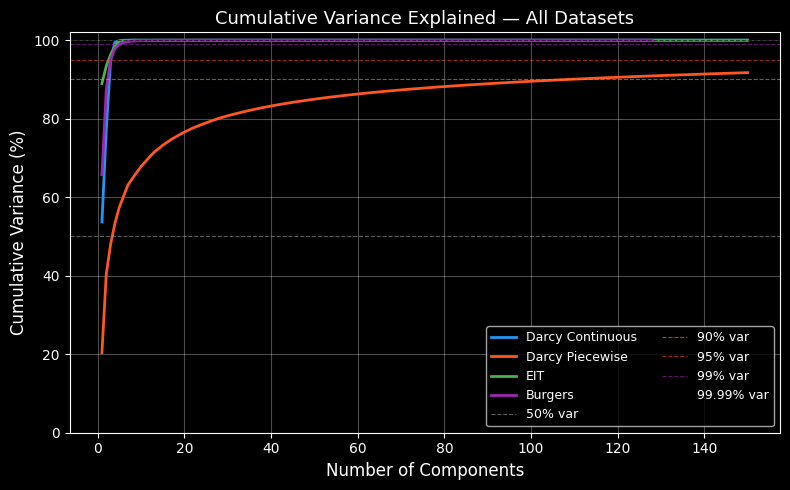

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

for (name, A, *_), color in zip(all_datasets_for_plots, colors):
    pca = pcas[name]
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    n_show = min(150, pca.n_components_)
    ax.plot(np.arange(1, n_show + 1), cumvar[:n_show] * 100,
            color=color, lw=2, label=name)

for t, label, tc in zip(THRESHOLDS, THRESHOLD_LABELS, threshold_colors):
    ax.axhline(t * 100, ls='--', lw=0.8, color=tc, alpha=0.6, label=f'{label} var')

ax.set_xlabel('Number of Components', fontsize=12)
ax.set_ylabel('Cumulative Variance (%)', fontsize=12)
ax.set_title('Cumulative Variance Explained — All Datasets', fontsize=13)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 102)

fig.tight_layout()
fig.savefig(FIGURE_DIR / 'cumvar_combined.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary Table (Pretty)

In [10]:
print('Dimensions needed to capture variance thresholds:')
print('=' * 65)
print(f'{"Dataset":<22s}', end='')
for label in THRESHOLD_LABELS:
    print(f'{label:>8s}', end='')
print()
print('-' * 65)
for _, row in df.iterrows():
    print(f'{row.name:<22s}', end='')
    for label in THRESHOLD_LABELS:
        print(f'{row[label]:>8d}', end='')
    print()
print('=' * 65)

print()
print('Current BETA_SIZE values:')
print('  Darcy Continuous: 6')
print('  Darcy Piecewise:  128')
print('  EIT:              6  (β_a only)')
print('  Burgers:          64 (current — from reference, not PCA-derived)')

Dimensions needed to capture variance thresholds:
Dataset                    50%     90%     95%     99%  99.99%
-----------------------------------------------------------------
Darcy Continuous             1       3       4       4       6
Darcy Piecewise              4     109     291     658     839
EIT                          1       2       3       5       8
Burgers                      1       3       3       6      19

Current BETA_SIZE values:
  Darcy Continuous: 6
  Darcy Piecewise:  128
  EIT:              6  (β_a only)
  Burgers:          64 (current — from reference, not PCA-derived)
